# Census Income Classification — Exploratory Data Analysis
**Goal:** Predict whether an individual earns `>$50,000` or `≤$50,000/year`  
**Data:** US Census Bureau — 199,523 rows, 42 features  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

BASE_DIR = os.path.abspath('..')
CLEAN_DATA = os.path.join(BASE_DIR, 'outputs', 'clean_data.pkl')

df = pd.read_pickle(CLEAN_DATA)
print(f'Shape: {df.shape}')
df.head()

Shape: (199523, 43)


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,income,target
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000,0
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000,0
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000,0
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000,0
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000,0


---
## 1. Dataset Overview

In [2]:
# Column types
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
# Remove label columns from feature lists
cat_cols = [c for c in cat_cols if c not in ('income', 'target')]

print(f'Numerical columns ({len(num_cols)}): {num_cols}')
print(f'\nCategorical columns ({len(cat_cols)}): {cat_cols}')

Numerical columns (14): ['age', 'detailed industry recode', 'detailed occupation recode', 'wage per hour', 'capital gains', 'capital losses', 'dividends from stocks', 'weight', 'num persons worked for employer', 'own business or self employed', 'veterans benefits', 'weeks worked in year', 'year', 'target']

Categorical columns (28): ['class of worker', 'education', 'enroll in edu inst last wk', 'marital stat', 'major industry code', 'major occupation code', 'race', 'hispanic origin', 'sex', 'member of a labor union', 'reason for unemployment', 'full or part time employment stat', 'tax filer stat', 'region of previous residence', 'state of previous residence', 'detailed household and family stat', 'detailed household summary in household', 'migration code-change in msa', 'migration code-change in reg', 'migration code-move within reg', 'live in this house 1 year ago', 'migration prev res in sunbelt', 'family members under 18', 'country of birth father', 'country of birth mother', 'count

In [3]:
# Summary statistics for numerical features
df[num_cols].describe().T.style.background_gradient(cmap='Blues', axis=1)

,count,mean,std,min,25%,50%,75%,max
age,199523.000000,34.494199,22.310895,0.000000,15.000000,33.000000,50.000000,90.000000
detailed industry recode,199523.000000,15.352320,18.067129,0.000000,0.000000,0.000000,33.000000,51.000000
detailed occupation recode,199523.000000,11.306556,14.454204,0.000000,0.000000,0.000000,26.000000,46.000000
wage per hour,199523.000000,55.426908,274.896454,0.000000,0.000000,0.000000,0.000000,9999.000000
capital gains,199523.000000,434.718990,4697.531280,0.000000,0.000000,0.000000,0.000000,99999.000000
capital losses,199523.000000,37.313788,271.896428,0.000000,0.000000,0.000000,0.000000,4608.000000
dividends from stocks,199523.000000,197.529533,1984.163658,0.000000,0.000000,0.000000,0.000000,99999.000000
weight,199523.000000,1740.380269,993.768156,37.870000,1061.615000,1618.310000,2188.610000,18656.300000
num persons worked for employer,199523.000000,1.956180,2.365126,0.000000,0.000000,1.000000,4.000000,6.000000
own business or self employed,199523.000000,0.175438,0.553694,0.000000,0.000000,0.000000,0.000000,2.000000


---
## 2. Target Class Distribution

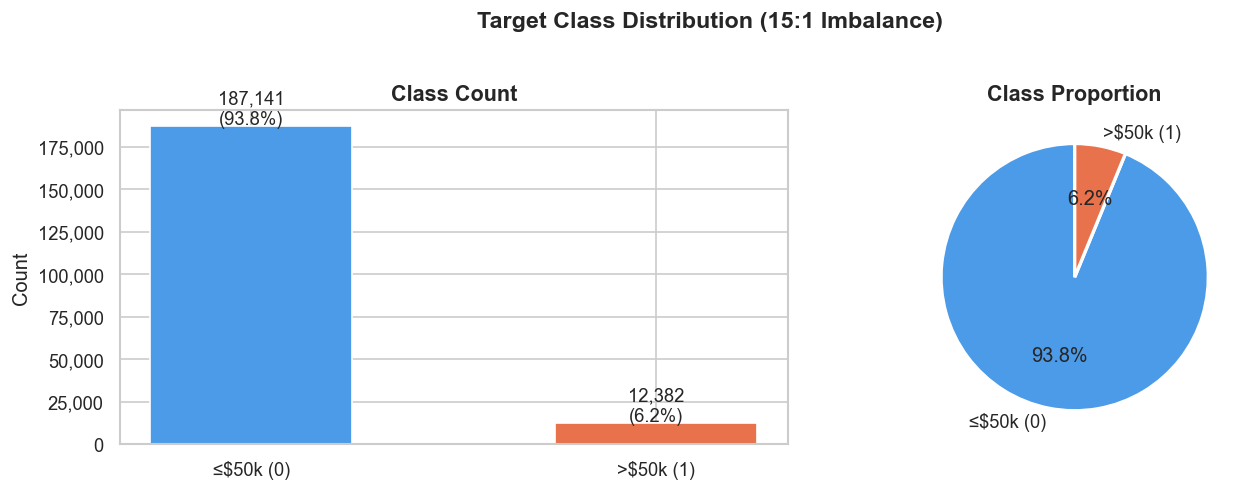

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['target'].value_counts().sort_index()
labels = ['≤$50k (0)', '>$50k (1)']
colors = ['#4C9BE8', '#E8724C']

# Bar chart
axes[0].bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11)
axes[0].set_title('Class Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

fig.suptitle('Target Class Distribution (15:1 Imbalance)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'eda', 'nb_target_distribution.png'), bbox_inches='tight')
plt.show()

---
## 3. Missing Values Analysis

In [5]:
# Count '?' as missing across all object columns
missing = df[cat_cols].apply(lambda col: (col == '?').sum()).sort_values(ascending=False)
missing = missing[missing > 0]
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'count': missing, 'percent (%)': missing_pct})
print('Columns with missing values:')
display(missing_df)


Columns with missing values:


,count,percent (%)
migration prev res in sunbelt,99696,49.97
migration code-move within reg,99696,49.97
migration code-change in reg,99696,49.97
migration code-change in msa,99696,49.97
country of birth father,6713,3.36
country of birth mother,6119,3.07
country of birth self,3393,1.70
state of previous residence,708,0.35


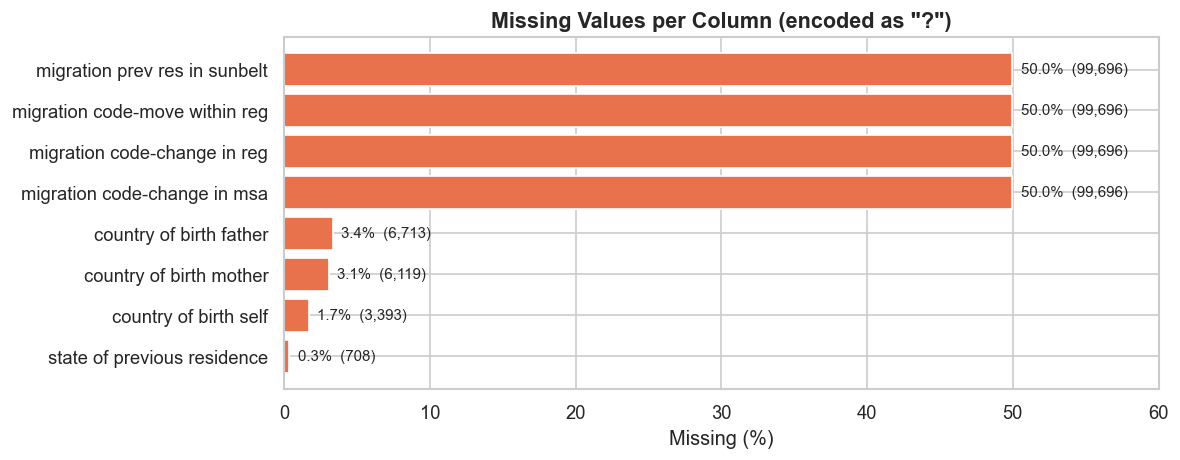

In [6]:
# Missing value bar chart
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(missing_df.index, missing_df['percent (%)'], color='#E8724C', edgecolor='white')
ax.bar_label(bars,
             labels=[f"{p:.1f}%  ({c:,})" for p, c in zip(missing_df['percent (%)'], missing_df['count'])],
             padding=5, fontsize=9)
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values per Column (encoded as "?")', fontsize=13, fontweight='bold')
ax.set_xlim(0, 60)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'eda', 'nb_missing_values.png'), bbox_inches='tight')
plt.show()


---
## 4. Numerical Feature Analysis

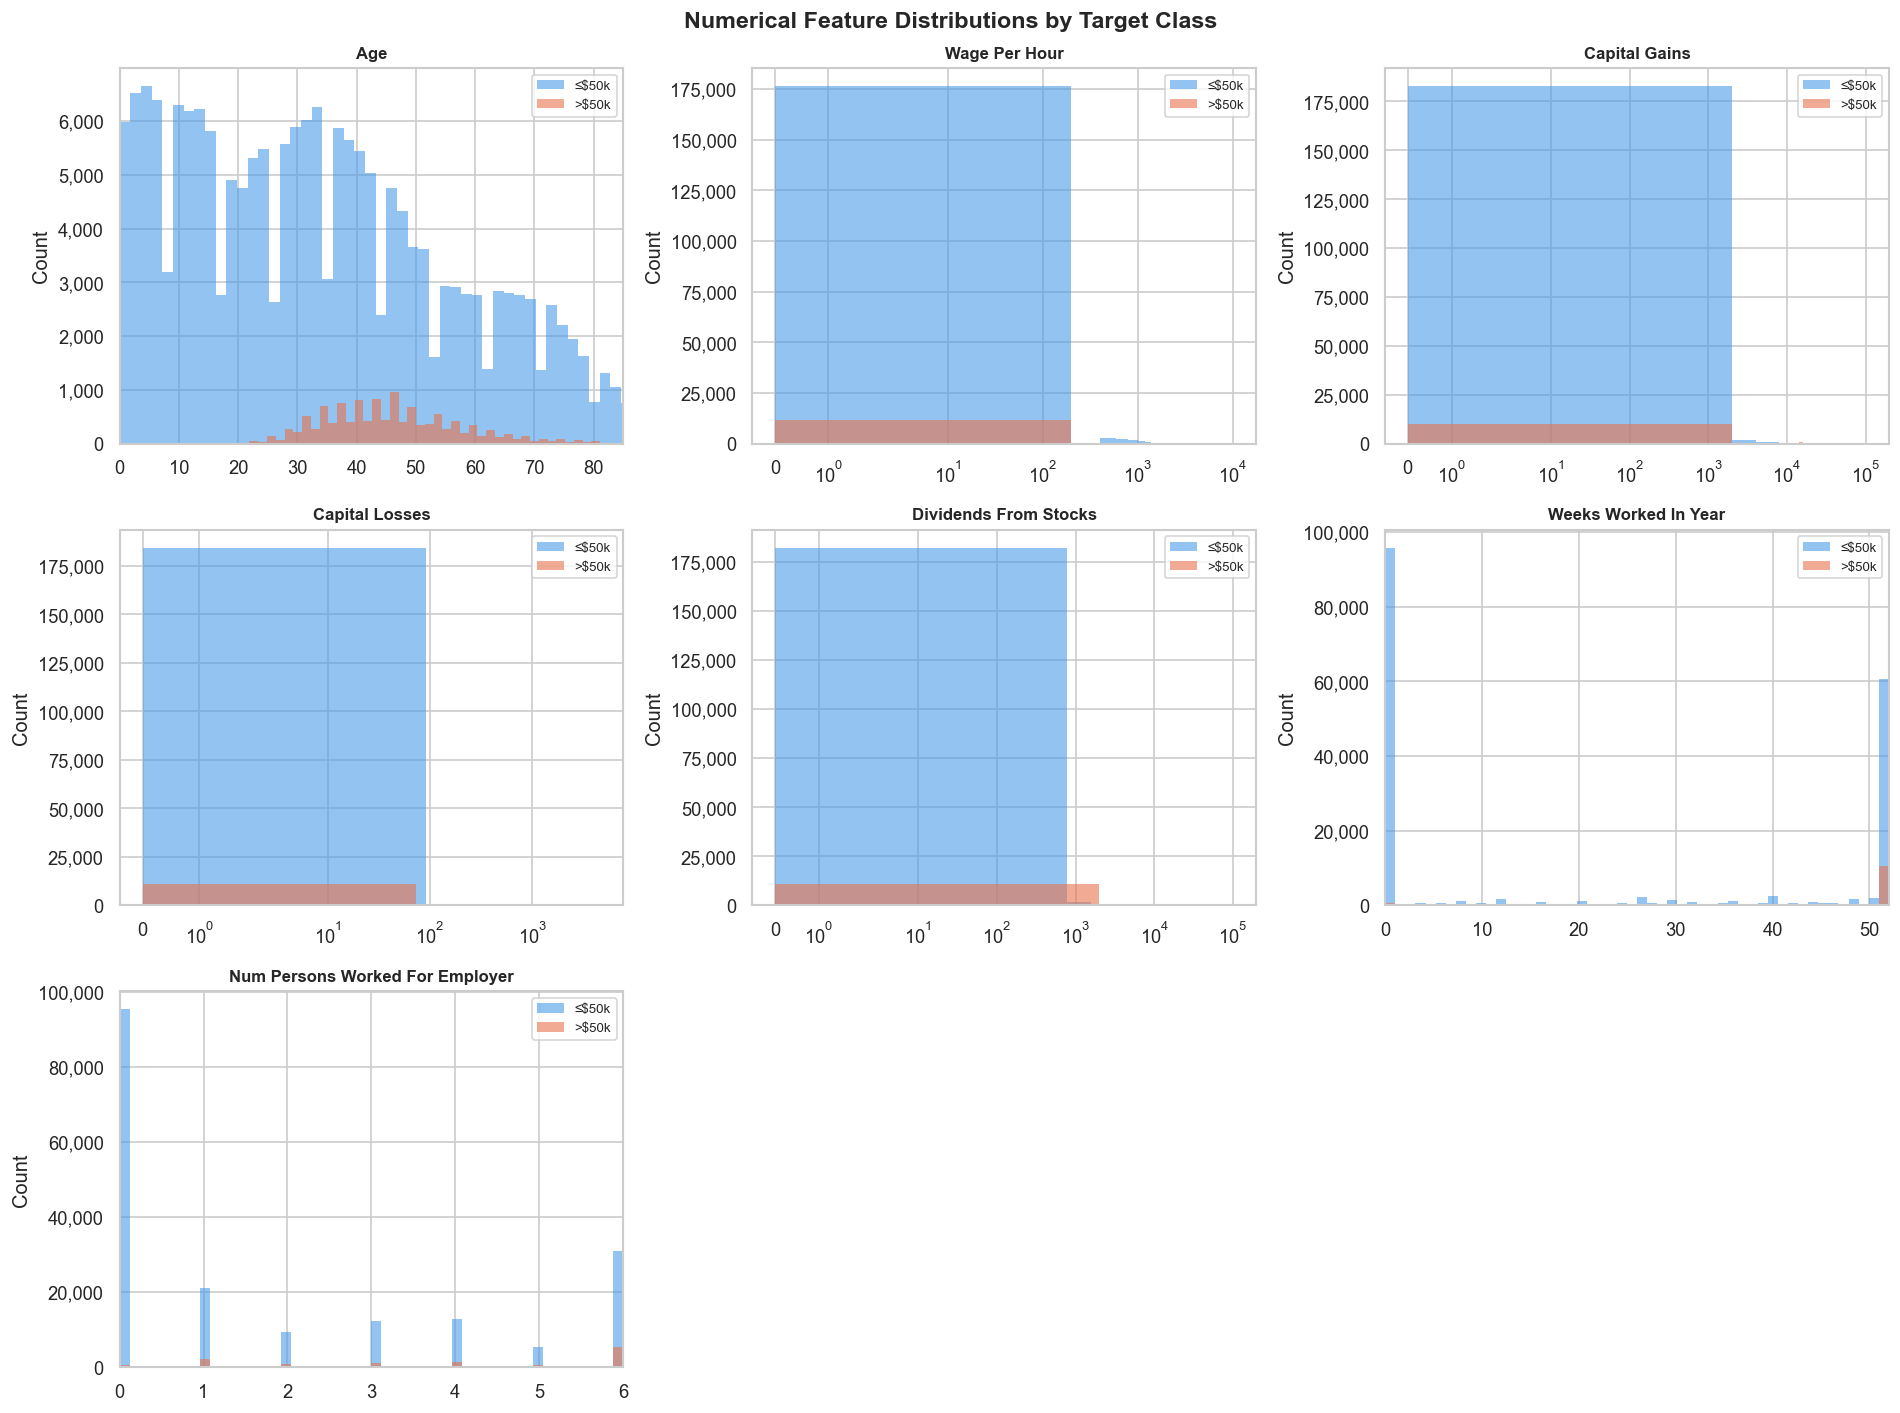

In [7]:
# Features to plot (exclude weight, year, own business, veterans benefits — less interesting)
num_plot_cols = [
    'age', 'wage per hour', 'capital gains',
    'capital losses', 'dividends from stocks', 'weeks worked in year',
    'num persons worked for employer',
]
log_scale_cols = {'capital gains', 'capital losses', 'dividends from stocks', 'wage per hour'}
palette = {0: '#4C9BE8', 1: '#E8724C'}
label_map = {0: '≤$50k', 1: '>$50k'}

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes_flat = axes.flatten()

for i, col in enumerate(num_plot_cols):
    ax = axes_flat[i]
    upper = df[col].quantile(0.99)
    for t in [0, 1]:
        data = df[df['target'] == t][col]
        ax.hist(data, bins=50, alpha=0.6, color=palette[t], label=label_map[t], edgecolor='none')
    if col in log_scale_cols:
        ax.set_xscale('symlog')   # symlog handles zeros gracefully
    else:
        ax.set_xlim(left=df[col].min(), right=upper)  # clip outliers at 99th percentile
    ax.set_title(col.title(), fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Hide unused subplots
for j in range(len(num_plot_cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Numerical Feature Distributions by Target Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'eda', 'nb_numerical_distributions.png'), bbox_inches='tight')
plt.show()


In [8]:
# Median values by target — quick signal check
print('Median by target class:')
df.groupby('target')[num_plot_cols].median().T.rename(columns=label_map)

Median by target class:


target,≤$50k,>$50k
age,31.0,45.0
wage per hour,0.0,0.0
capital gains,0.0,0.0
capital losses,0.0,0.0
dividends from stocks,0.0,0.0
weeks worked in year,0.0,52.0
num persons worked for employer,0.0,4.0


---
## 5. Categorical Feature Analysis

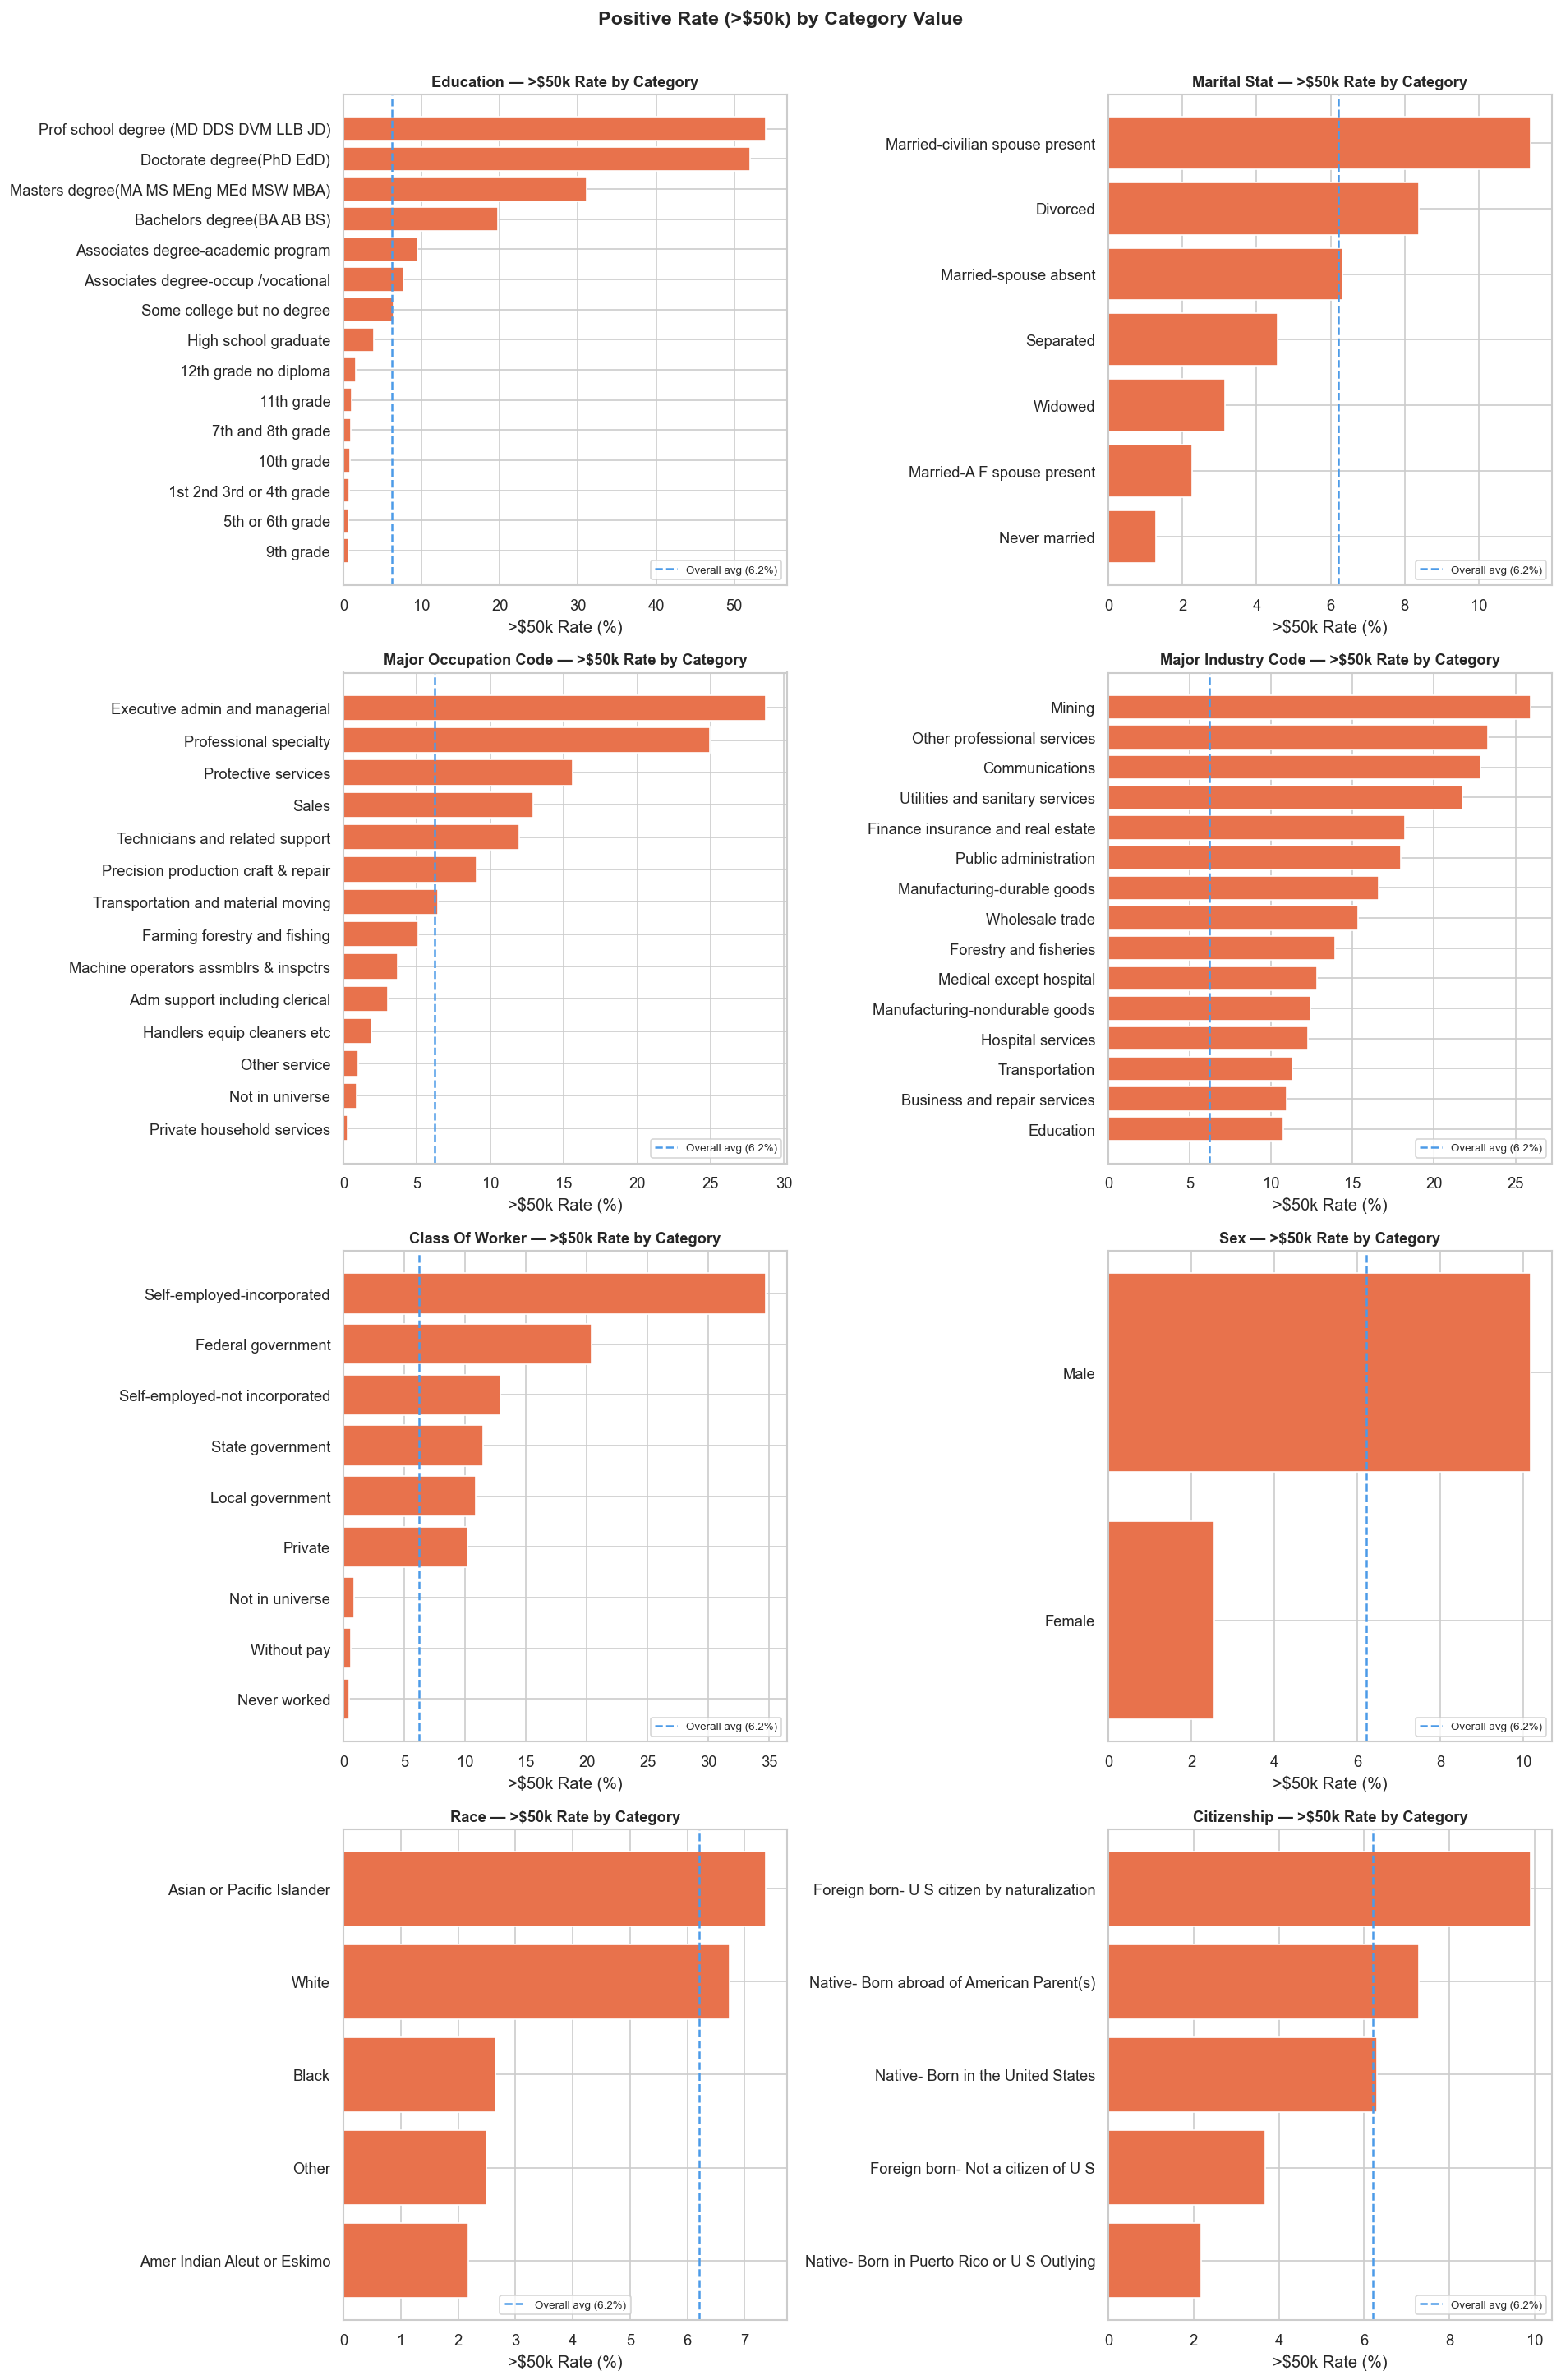

In [9]:
# For each categorical feature: positive rate per category (most informative view)
def plot_positive_rate(col, top_n=15, ax=None, min_count=100):
    stats = (
        df.groupby(col)['target']
          .agg(['mean', 'count'])
          .rename(columns={'mean': 'positive_rate', 'count': 'n'})
          .query('n >= @min_count')
          .sort_values('positive_rate', ascending=False)
          .head(top_n)
    )
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(stats.index[::-1], stats['positive_rate'][::-1] * 100,
                   color='#E8724C', edgecolor='white')
    ax.axvline(df['target'].mean() * 100, color='#4C9BE8', linestyle='--',
               linewidth=1.5, label=f'Overall avg ({df["target"].mean()*100:.1f}%)')
    ax.set_xlabel('>$50k Rate (%)')
    ax.set_title(f'{col.title()} — >$50k Rate by Category', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    return ax

key_cats = ['education', 'marital stat', 'major occupation code', 'major industry code',
            'class of worker', 'sex', 'race', 'citizenship']

fig, axes = plt.subplots(4, 2, figsize=(16, 24))
for ax, col in zip(axes.flatten(), key_cats):
    plot_positive_rate(col, ax=ax)

fig.suptitle('Positive Rate (>$50k) by Category Value', fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'eda', 'nb_positive_rates.png'), bbox_inches='tight')
plt.show()

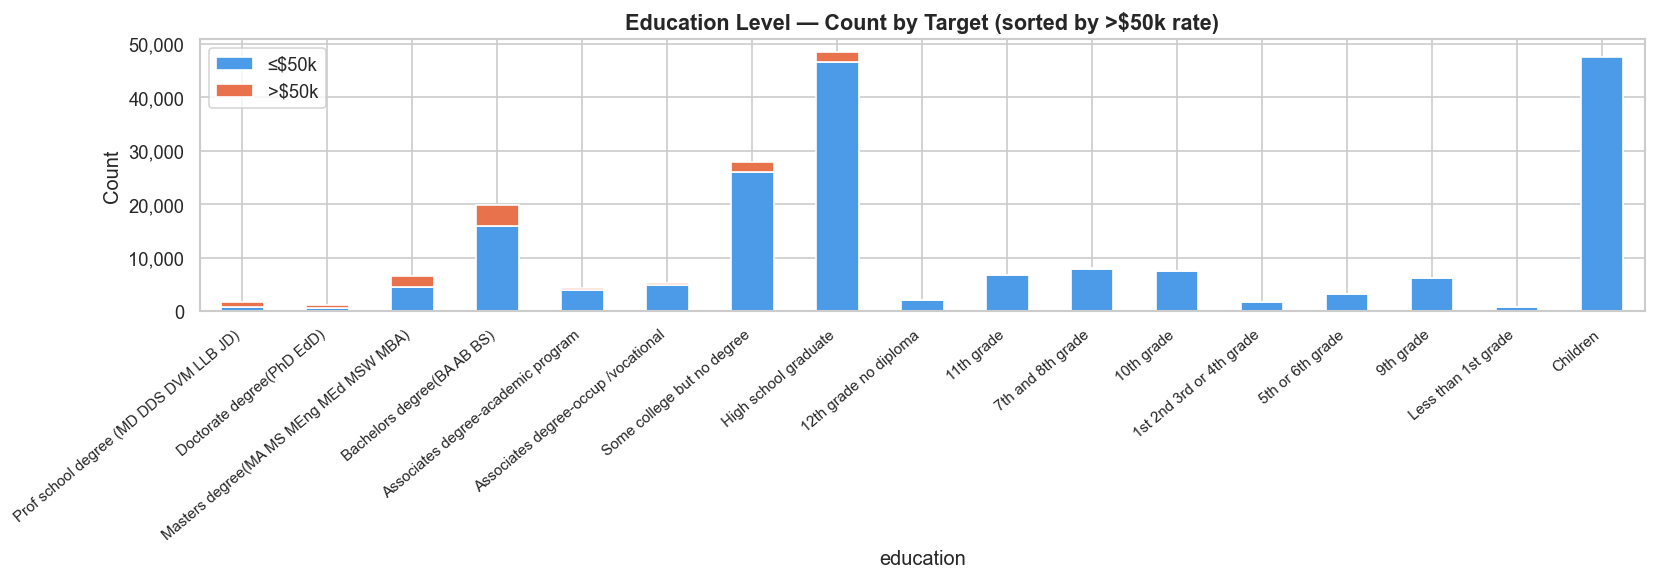

In [10]:
# Stacked bar: education × target (count)
edu_order = (
    df.groupby('education')['target'].mean()
      .sort_values(ascending=False).index.tolist()
)

edu_counts = (
    df.groupby(['education', 'target'])
      .size().unstack(fill_value=0)
      .loc[edu_order]
)

fig, ax = plt.subplots(figsize=(14, 5))
edu_counts.plot(kind='bar', stacked=True, ax=ax,
                color=['#4C9BE8', '#E8724C'], edgecolor='white')
ax.set_xticklabels(edu_order, rotation=40, ha='right', fontsize=9)
ax.set_title('Education Level — Count by Target (sorted by >$50k rate)', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.legend(['≤$50k', '>$50k'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'eda', 'nb_education_stacked.png'), bbox_inches='tight')
plt.show()

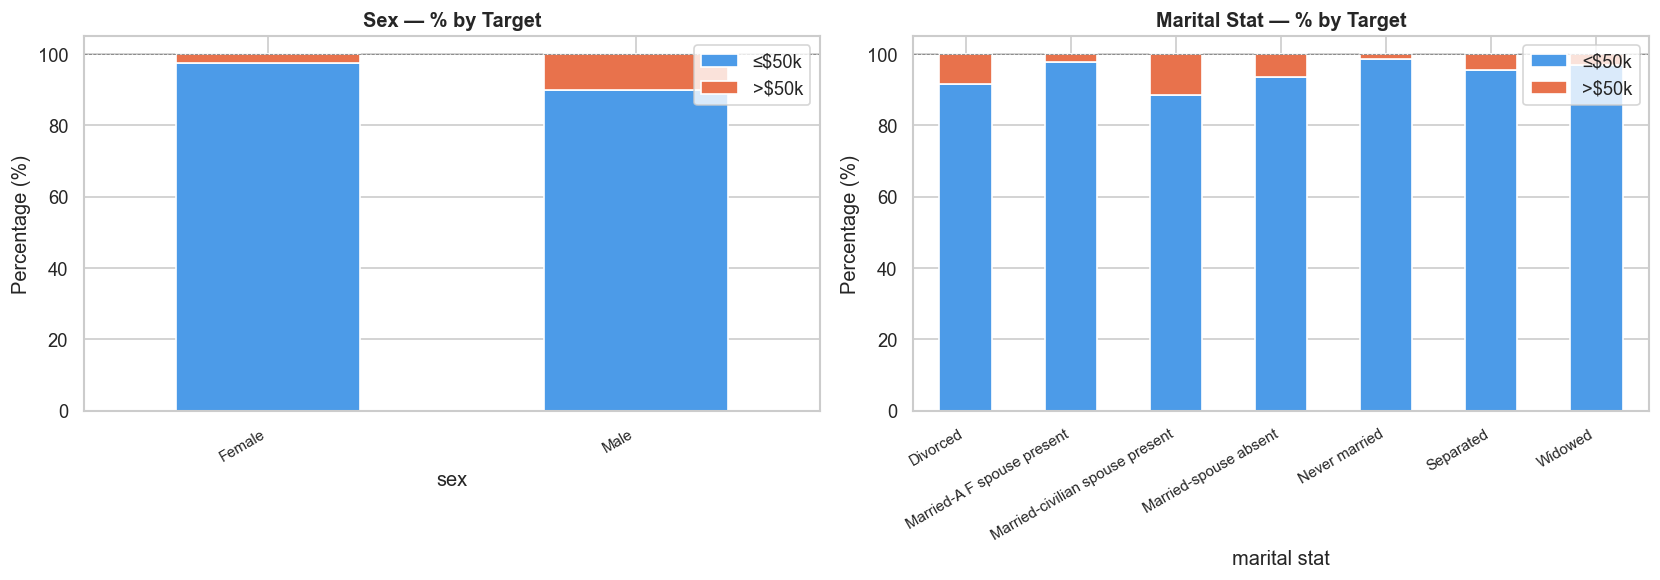

In [11]:
# Sex and marital status cross-tab
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['sex', 'marital stat']):
    ct = df.groupby([col, 'target']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', stacked=True, ax=ax,
                color=['#4C9BE8', '#E8724C'], edgecolor='white')
    ax.set_xticklabels(ct_pct.index, rotation=30, ha='right', fontsize=9)
    ax.set_title(f'{col.title()} — % by Target', fontsize=12, fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ax.legend(['≤$50k', '>$50k'], loc='upper right')
    ax.axhline(100, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'eda', 'nb_sex_marital_pct.png'), bbox_inches='tight')
plt.show()

---
## 6. Correlation & Feature Relationships

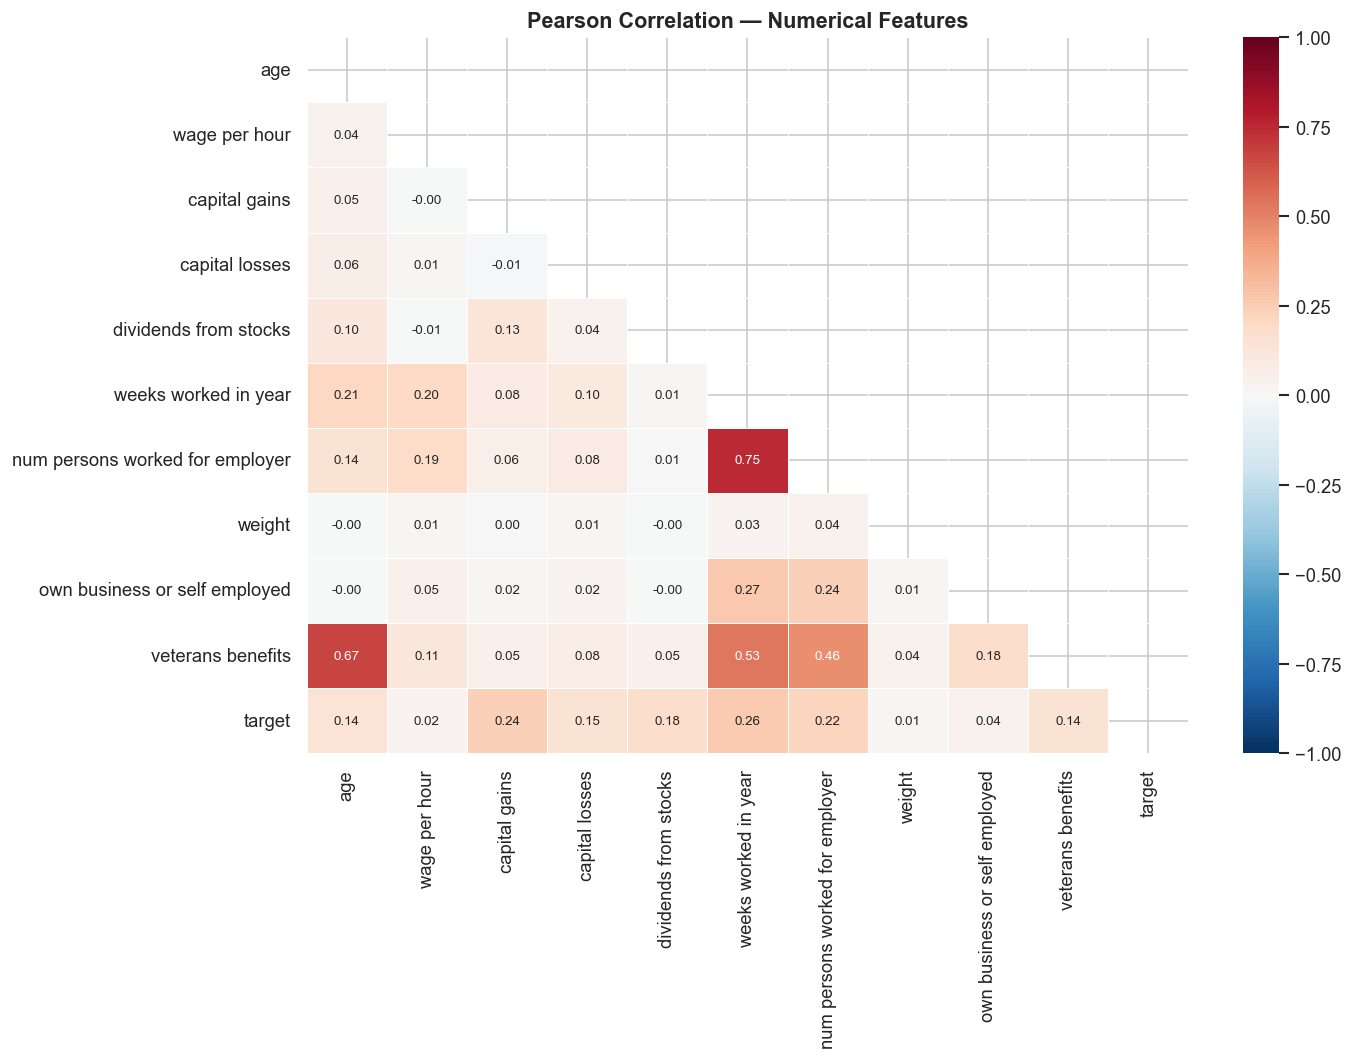


Correlation with target (sorted):
weeks worked in year               0.262316
capital gains                      0.240725
num persons worked for employer    0.222684
dividends from stocks              0.175779
capital losses                     0.147417
veterans benefits                  0.140930
age                                0.135720
own business or self employed      0.040473
wage per hour                      0.024528
weight                             0.014463


In [12]:
# Correlation matrix for numerical features + target
corr_cols = num_plot_cols + ['weight', 'own business or self employed', 'veterans benefits', 'target']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Pearson Correlation — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'eda', 'nb_correlation_heatmap.png'), bbox_inches='tight')
plt.show()

print('\nCorrelation with target (sorted):')
print(corr['target'].drop('target').sort_values(ascending=False).to_string())

In [13]:
# Point-biserial correlation — numerical features vs target
from scipy.stats import pointbiserialr

pb_results = []
for col in num_plot_cols + ['weight', 'own business or self employed', 'veterans benefits', 'year']:
    r, p = pointbiserialr(df['target'], df[col])
    pb_results.append({'feature': col, 'correlation (r)': round(r, 4), 'p_value': round(p, 6)})

pb_df = pd.DataFrame(pb_results).sort_values('correlation (r)', ascending=False)
print('Point-biserial correlation with target (sorted):')
display(pb_df.reset_index(drop=True))


Point-biserial correlation with target (sorted):


,feature,correlation (r),p_value
0,weeks worked in year,0.2623,0.0
1,capital gains,0.2407,0.0
2,num persons worked for employer,0.2227,0.0
3,dividends from stocks,0.1758,0.0
4,capital losses,0.1474,0.0
5,veterans benefits,0.1409,0.0
6,age,0.1357,0.0
7,own business or self employed,0.0405,0.0
8,wage per hour,0.0245,0.0
9,year,0.0148,0.0


In [14]:
# Cramér V — categorical feature association with target
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct, correction=False)[0]
    n = ct.sum().sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

cv_results = []
for col in cat_cols:
    v = cramers_v(df[col], df['target'])
    cv_results.append({'feature': col, 'Cramér V': round(v, 4)})

cv_df = pd.DataFrame(cv_results).sort_values('Cramér V', ascending=False).reset_index(drop=True)
print('Cramér V — categorical association with target (sorted):')
display(cv_df)


Cramér V — categorical association with target (sorted):


,feature,Cramér V
0,education,0.3898
1,major occupation code,0.3663
2,major industry code,0.2779
3,class of worker,0.2605
4,detailed household and family stat,0.2405
5,tax filer stat,0.2292
6,detailed household summary in household,0.2272
7,marital stat,0.1977
8,full or part time employment stat,0.1598
9,family members under 18,0.1592


---
## 7. Age Deep-Dive


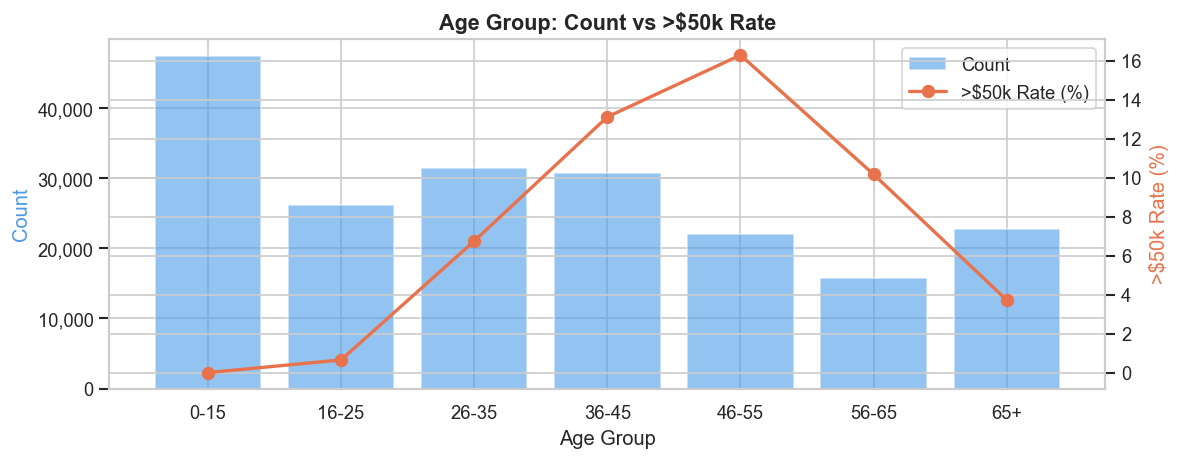

         positive_rate  count
age_bin                      
0-15          0.000000  47509
16-25         0.006514  26251
26-35         0.067467  31556
36-45         0.131129  30817
46-55         0.162848  22082
56-65         0.101653  15730
65+           0.037205  22739


In [15]:
# Positive rate and count by age group
df['age_bin'] = pd.cut(df['age'], bins=[0,15,25,35,45,55,65,100],
                        labels=['0-15','16-25','26-35','36-45','46-55','56-65','65+'])

age_stats = df.groupby('age_bin', observed=True)['target'].agg(['mean','count'])
age_stats.columns = ['positive_rate', 'count']

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.bar(age_stats.index, age_stats['count'], color='#4C9BE8', alpha=0.6, label='Count')
ax2.plot(age_stats.index, age_stats['positive_rate']*100, 'o-',
         color='#E8724C', linewidth=2, markersize=7, label='>$50k Rate (%)')
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Count', color='#4C9BE8')
ax2.set_ylabel('>$50k Rate (%)', color='#E8724C')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper right')
ax1.set_title('Age Group: Count vs >$50k Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'eda', 'nb_age_analysis.png'), bbox_inches='tight')
plt.show()
print(age_stats)
df.drop(columns='age_bin', inplace=True)


---
## 8. Financial Feature Deep-Dive


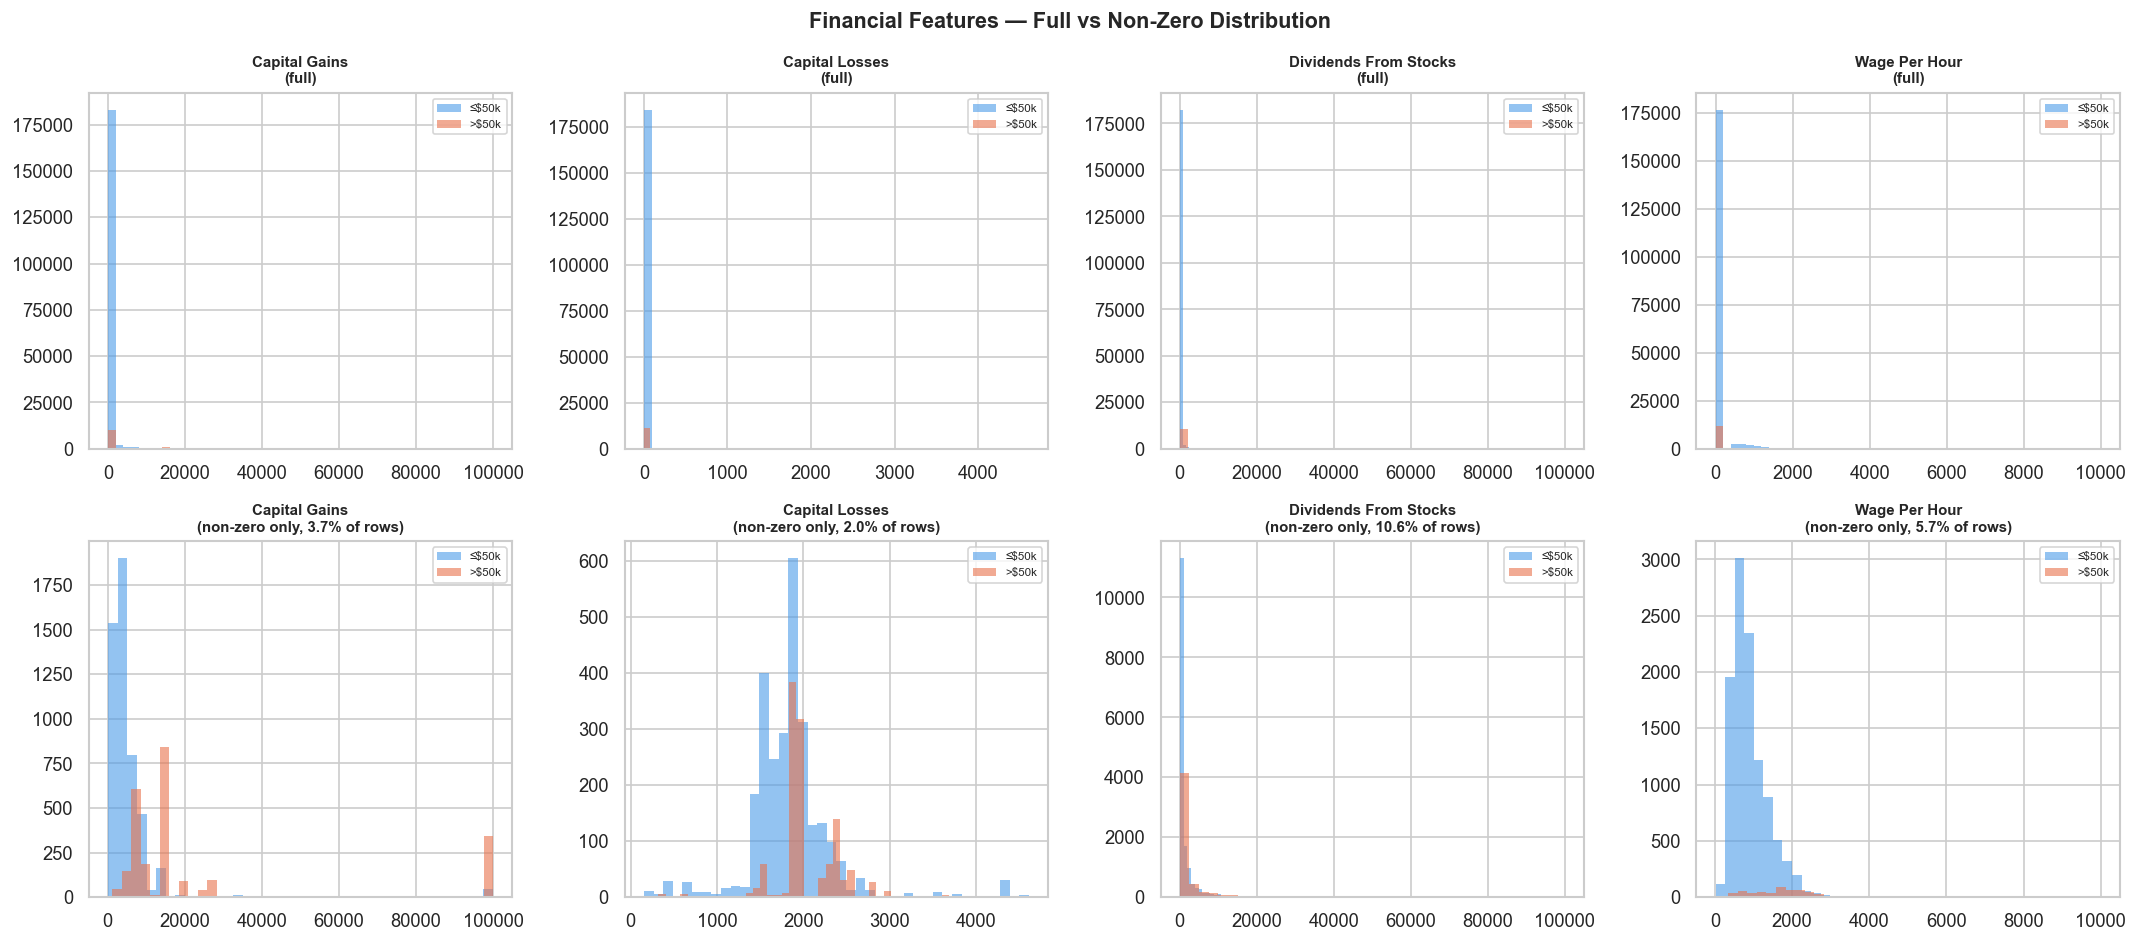


Positive rate for non-zero rows:
  capital gains: 32.7%  (vs overall 6.2%)
  capital losses: 29.9%  (vs overall 6.2%)
  dividends from stocks: 25.1%  (vs overall 6.2%)
  wage per hour: 4.9%  (vs overall 6.2%)


In [16]:
# Full vs non-zero distributions for financial columns
financial_cols = ['capital gains', 'capital losses', 'dividends from stocks', 'wage per hour']
palette = {0: '#4C9BE8', 1: '#E8724C'}
label_map = {0: '≤$50k', 1: '>$50k'}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(financial_cols):
    # Top row: full distribution
    ax = axes[0, i]
    for t in [0, 1]:
        ax.hist(df[df['target']==t][col], bins=50, alpha=0.6,
                color=palette[t], label=label_map[t], edgecolor='none')
    ax.set_title(f'{col.title()}\n(full)', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)
    # Bottom row: non-zero only
    ax2 = axes[1, i]
    nonzero = df[df[col] > 0]
    pct_nonzero = len(nonzero)/len(df)*100
    for t in [0, 1]:
        ax2.hist(nonzero[nonzero['target']==t][col], bins=40, alpha=0.6,
                 color=palette[t], label=label_map[t], edgecolor='none')
    ax2.set_title(f'{col.title()}\n(non-zero only, {pct_nonzero:.1f}% of rows)', fontsize=9, fontweight='bold')
    ax2.legend(fontsize=7)

fig.suptitle('Financial Features — Full vs Non-Zero Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'eda', 'nb_financial_features.png'), bbox_inches='tight')
plt.show()

print('\nPositive rate for non-zero rows:')
for col in financial_cols:
    rate = df[df[col] > 0]['target'].mean() * 100
    print(f'  {col}: {rate:.1f}%  (vs overall 6.2%)')


---
## 9. Drop & Impute Decisions


In [17]:
# Drop & impute decision table
drop_decisions = pd.DataFrame([
    {'column': 'migration code-change in msa',          'missing %': '50%', 'signal': 'V=0.039', 'decision': 'DROP',         'reason': '50% missing, structural survey gap, near-zero signal'},
    {'column': 'migration code-change in reg',           'missing %': '50%', 'signal': 'V=0.038', 'decision': 'DROP',         'reason': '50% missing, structural survey gap, near-zero signal'},
    {'column': 'migration code-move within reg',         'missing %': '50%', 'signal': 'V=0.038', 'decision': 'DROP',         'reason': '50% missing, structural survey gap, near-zero signal'},
    {'column': 'migration prev res in sunbelt',          'missing %': '50%', 'signal': 'V=0.029', 'decision': 'DROP',         'reason': '50% missing, structural survey gap, near-zero signal'},
    {'column': 'weight',                                 'missing %': '0%',  'signal': 'N/A',     'decision': 'DROP',         'reason': 'Census sampling weight — survey design, not individual feature'},
    {'column': 'year',                                   'missing %': '0%',  'signal': 'r=+0.015','decision': 'DROP',         'reason': 'Only 2 values (94/95), negligible positive-rate difference'},
    {'column': 'country of birth father',                'missing %': '3.4%','signal': 'V=0.072', 'decision': 'KEEP + IMPUTE','reason': 'Small % missing — replace ? with Unknown'},
    {'column': 'country of birth mother',                'missing %': '3.1%','signal': 'V=0.071', 'decision': 'KEEP + IMPUTE','reason': 'Small % missing — replace ? with Unknown'},
    {'column': 'country of birth self',                  'missing %': '1.7%','signal': 'V=0.061', 'decision': 'KEEP + IMPUTE','reason': 'Small % missing — replace ? with Unknown'},
    {'column': 'state of previous residence',            'missing %': '0.4%','signal': 'V=0.033', 'decision': 'KEEP + IMPUTE','reason': 'Small % missing — replace ? with Unknown'},
])
display(drop_decisions)


,column,missing %,signal,decision,reason
0,migration code-change in msa,50%,V=0.039,DROP,"50% missing, structural survey gap, near-zero ..."
1,migration code-change in reg,50%,V=0.038,DROP,"50% missing, structural survey gap, near-zero ..."
2,migration code-move within reg,50%,V=0.038,DROP,"50% missing, structural survey gap, near-zero ..."
3,migration prev res in sunbelt,50%,V=0.029,DROP,"50% missing, structural survey gap, near-zero ..."
4,weight,0%,N/A,DROP,"Census sampling weight — survey design, not in..."
5,year,0%,r=+0.015,DROP,"Only 2 values (94/95), negligible positive-rat..."
6,country of birth father,3.4%,V=0.072,KEEP + IMPUTE,Small % missing — replace ? with Unknown
7,country of birth mother,3.1%,V=0.071,KEEP + IMPUTE,Small % missing — replace ? with Unknown
8,country of birth self,1.7%,V=0.061,KEEP + IMPUTE,Small % missing — replace ? with Unknown
9,state of previous residence,0.4%,V=0.033,KEEP + IMPUTE,Small % missing — replace ? with Unknown


---
## 10. Key Findings Summary

| Finding | Implication |
|---|---|
| **15:1 class imbalance** (6.2% positive) | Use F1/AUC metrics; `class_weight='balanced'` on all models |
| **Capital gains, dividends, weeks worked** are the strongest numerical signals | Apply log1p transform; add binary is-nonzero flags |
| **Occupation (V=0.44) and education (V=0.39)** are the strongest categorical signals | Keep detailed occupation recode over major codes |
| **4 migration columns are 50% missing** | Drop — structural survey gap, not recoverable |
| **Age < 16 = 25% of data, 0% positive rate** | Tree models will learn this split automatically |
| **Weeks worked == 52** (full-year) is a clean binary signal | Add `is_fulltime_year` flag |
| **Wage per hour non-zero positive rate (4.9%) < population average (6.2%)** | Low-priority feature; salaried workers have wage=0 |
